# 节假日特征对比（dinov3）

**位置**: `comp/tune/` · **Kernel: `dinov3`** · 比赛流程见 [`../work.ipynb`](../work.ipynb)

```bash
conda activate dinov3
cd comp/tune
pip install -r requirements_extra.txt
```

| 方案 | holiday | 说明 |
|------|---------|------|
| baseline | `None` | 31 维 |
| **v1** | `'v1'` | 节前3+节中+节后2 |
| **v2b** | `'v2b'` | 节前14+节中 |
| **v3** | `'v3'` | rank-k + 同月同日 |
| **v4_1** | — | 硬门控混合专家 |

代码：`lib_feat_ext.py`（特征）· `lib_exp.py`（训树/v4_1）

In [8]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path
COMP = Path('..').resolve()
sys.path[:0] = [str(COMP), str(Path.cwd().resolve())]

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from lib_clean import load, PATH_TRAIN, PATH_TEST
from lib_feat import TIME, TARGET
from lib_feat_ext import HOLIDAY_V1, HOLIDAY_V2B, HOLIDAY_V3
from lib_comp import load_params
from lib_exp import make_seg_lookup, run_trees, run_v4_1, TREE_MAX_ROUNDS

params = load_params()
TREES = params['trees']
EXPERT_TREE = 'lgb'

VAL_START_OVERRIDE = None
VAL_START = str(VAL_START_OVERRIDE or params['val_start'])[:10]

VARIANTS = [
    ('baseline', None, 'std'),
    ('v1', 'v1', 'std'),
    ('v2b', 'v2b', 'std'),
    ('v3', 'v3', 'std'),
    ('v4_1', None, 'v4_1'),
]
print('val_start:', VAL_START)
print('variants:', [v[0] for v in VARIANTS])

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
val_start: 2025-04-03 (params.json)
variants: ['baseline', 'v1', 'v2b', 'v3', 'v4_1']
v1 (3+hol+2): ['hol_active', 'hol_days', 'hol_lagy']
v2b (14+hol): ['hol_active', 'hol_days', 'hol_lagy']
v3: ['hol_type', 'hol_days_v3', 'hol_lagy_rank', 'hol_lagy_cal']


In [9]:
df_hist, df_test = load(PATH_TRAIN, PATH_TEST)
df_all = pd.concat([df_hist, df_test]).sort_values(TIME).reset_index(drop=True)

ts = pd.to_datetime(VAL_START)
ht = pd.to_datetime(df_hist[TIME])
n_train = (ht < ts).sum()
n_val = (ht >= ts).sum()
print(f'hist={len(df_hist)}  test={len(df_test)}')
print(f'val_start={VAL_START}  →  train={n_train}  val={n_val}  (15min 点数)')
print(f'  train: {ht.min().date()} ~ {(ht[ht < ts].max().date() if n_train else "—")}')
print(f'  val:   {(ht[ht >= ts].min().date() if n_val else "—")} ~ {ht.max().date()}')
print(f'  test:  {pd.to_datetime(df_test[TIME]).min().date()} ~ {pd.to_datetime(df_test[TIME]).max().date()}')

hist=116734  test=2880
val_start=2025-04-03  →  train=114048  val=2686  (15min 点数)
  train: 2022-01-01 ~ 2025-04-02
  val:   2025-04-03 ~ 2025-04-30
  test:  2025-05-01 ~ 2025-05-30


c:\Users\zhich\OneDrive\Desktop\github\竞赛\202608调度\comp\.\lib_clean.py:37: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  return df.interpolate('time').ffill().bfill().reset_index(names=TIME)
c:\Users\zhich\OneDrive\Desktop\github\竞赛\202608调度\comp\.\lib_clean.py:37: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  return df.interpolate('time').ffill().bfill().reset_index(names=TIME)


In [ ]:
SEG_LOOKUP = make_seg_lookup(df_all)


In [11]:
rows, packs = [], {}
for label, mode, kind in VARIANTS:
    print(f"\n=== {label} (holiday={mode}, kind={kind}) ===")
    if kind == 'v4_1':
        row, pack = run_v4_1(df_all, df_test, VAL_START, TREES, params, SEG_LOOKUP,
                             label=label, expert_tree=EXPERT_TREE)
    else:
        row, pack = run_trees(df_all, df_test, VAL_START, TREES, params, mode, label, SEG_LOOKUP)
    rows.append(row)
    packs[label] = pack
    extra = ''
    if kind == 'v4_1':
        extra = (f"  hol_n={row.get('hol_train_n')} ext_n={row.get('ext_train_n')}"
                 f"  w_hol={row.get('gate_w_hol', float('nan')):.2f}"
                 f"  w_ext={row.get('gate_w_ext', float('nan')):.2f}"
                 f"  hol_iter={row.get('hol_expert_iter')}")
    print(f"stack val={row['stack_val_mape']:.2f}%  test={row.get('stack_test_mape', float('nan')):.2f}%  "
          f"may1_5={row.get('stack_test_may1_5_mape', float('nan')):.2f}%  "
          f"LGB iter={row.get('lgb_best_iter')}/{TREE_MAX_ROUNDS}{extra}")

cmp = pd.DataFrame(rows)
cmp



=== baseline (holiday=None, kind=std) ===
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[673]	valid_0's l2: 594465
stack val=2.26%  test=2.55%  may1_5=2.29%  LGB iter=673/1500

=== v1 (holiday=v1, kind=std) ===
Training until validation scores don't improve for 100 rounds
Did not meet early stopping. Best iteration is:
[1447]	valid_0's l2: 537255
stack val=2.26%  test=2.63%  may1_5=2.42%  LGB iter=1447/1500

=== v2b (holiday=v2b, kind=std) ===
Training until validation scores don't improve for 100 rounds
Did not meet early stopping. Best iteration is:
[1500]	valid_0's l2: 542506
stack val=2.24%  test=2.51%  may1_5=2.31%  LGB iter=1500/1500

=== v3 (holiday=v3, kind=std) ===
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[1344]	valid_0's l2: 554412
stack val=2.24%  test=2.55%  may1_5=2.35%  LGB iter=1344/1500

=== v4_1 (holiday=None, kind=v4_1) ===
Training until validation scores don't

,variant,holiday,n_feats,stack_val_mape,lgb_best_iter,lgb_val_mape,xgb_val_mape,cat_val_mape,stack_val_full_mape,stack_val_fdjjr_mape,...,stack_test_may1_5_mape,stack_test_fdjjr_mape,hol_expert_iter,ext_expert_iter,hol_train_n,ext_train_n,gate_w_hol,gate_w_ext,val_hol_seg_mape,val_ext_seg_mape
0,baseline,None,31,2.263997,673,2.590930,2.476273,2.428918,2.263997,2.448016,...,2.286690,2.286690,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,v1,v1,34,2.262873,1447,2.454314,2.594872,2.381715,2.262873,2.318416,...,2.418137,2.418137,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,v2b,v2b,34,2.243352,1500,2.419695,2.565613,2.465913,2.243352,2.368154,...,2.306819,2.306819,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,v3,v3,35,2.235853,1344,2.464954,2.543140,2.400097,2.235853,2.237194,...,2.354452,2.354452,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,v4_1,v4_1,31,2.283706,673,2.590930,2.476273,2.428918,2.283706,2.500447,...,2.438163,2.438163,30.0,1500.0,18910.0,33460.0,0.8,0.8,1.803659,5.565161


In [12]:
seg_cols = ['variant', 'holiday', 'n_feats', 'lgb_best_iter',
            'stack_val_mape', 'stack_val_may1_5_mape', 'stack_val_fdjjr_mape', 'stack_val_pre7_mape',
            'stack_test_mape', 'stack_test_may1_5_mape', 'stack_test_fdjjr_mape', 'stack_test_pre7_mape']
seg_cols = [c for c in seg_cols if c in cmp.columns]
print(cmp[seg_cols].to_string(index=False))

if 'stack_test_mape' in cmp.columns:
    base = cmp[cmp['variant'] == 'baseline'].iloc[0]
    for seg in ['stack_test_mape', 'stack_test_may1_5_mape', 'stack_test_fdjjr_mape']:
        if seg not in cmp.columns:
            continue
        d = cmp[['variant', seg]].copy()
        d['delta_vs_baseline'] = d[seg] - base[seg]
        print(f'\n{seg} vs baseline (负=更好):')
        print(d.to_string(index=False))

 variant holiday  n_feats  lgb_best_iter  stack_val_mape  stack_val_fdjjr_mape  stack_val_pre7_mape  stack_test_mape  stack_test_may1_5_mape  stack_test_fdjjr_mape
baseline    None       31            673        2.263997              2.448016             1.329940         2.550968                2.286690               2.286690
      v1      v1       34           1447        2.262873              2.318416             1.577968         2.631021                2.418137               2.418137
     v2b     v2b       34           1500        2.243352              2.368154             1.406886         2.505883                2.306819               2.306819
      v3      v3       35           1344        2.235853              2.237194             1.314807         2.554875                2.354452               2.354452
    v4_1    v4_1       31            673        2.283706              2.500447             1.284992         2.571102                2.438163               2.438163

stack_test_mape

C:\Users\zhich\AppData\Local\Temp\ipykernel_22976\3167297673.py:44: UserWarning: Glyph 20840 (\N{CJK UNIFIED IDEOGRAPH-5168}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\zhich\AppData\Local\Temp\ipykernel_22976\3167297673.py:44: UserWarning: Glyph 21475 (\N{CJK UNIFIED IDEOGRAPH-53E3}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\zhich\AppData\Local\Temp\ipykernel_22976\3167297673.py:44: UserWarning: Glyph 24452 (\N{CJK UNIFIED IDEOGRAPH-5F84}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\zhich\AppData\Local\Temp\ipykernel_22976\3167297673.py:44: UserWarning: Glyph 21457 (\N{CJK UNIFIED IDEOGRAPH-53D1}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\zhich\AppData\Local\Temp\ipykernel_22976\3167297673.py:44: UserWarning: Glyph 36141 (\N{CJK UNIFIED IDEOGRAPH-8D2D}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\zhich\AppData\Local\Temp\ipykernel_22976\3167297673.py:44: UserWarning: Glyph 39044 (\

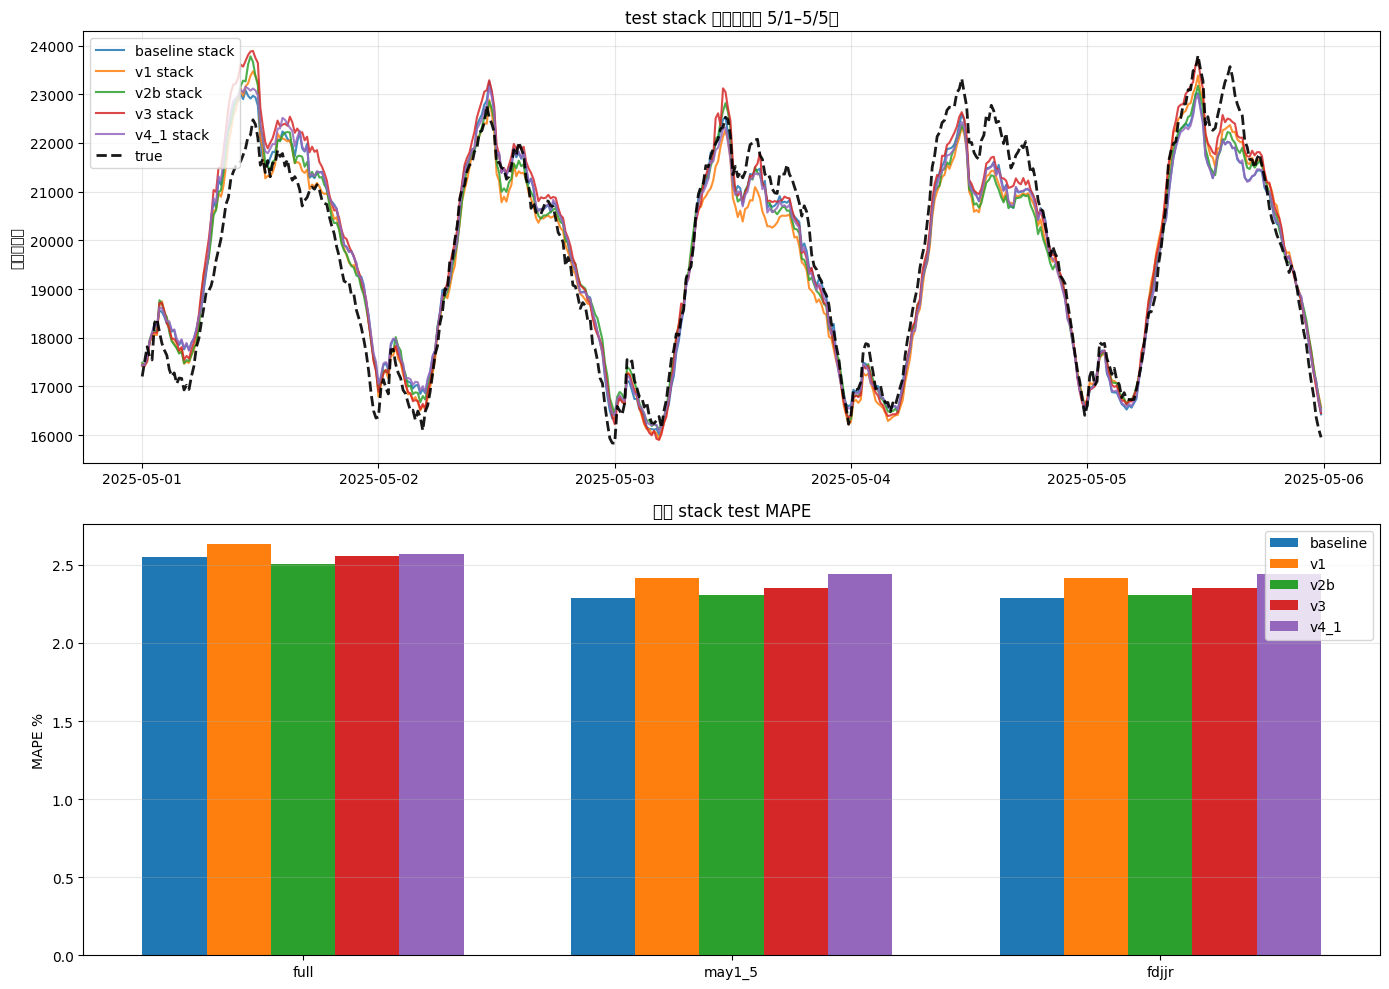

In [13]:
plot_variants = ['baseline', 'v1', 'v2b', 'v3', 'v4_1']
colors = {'baseline': 'C0', 'v1': 'C1', 'v2b': 'C2', 'v3': 'C3', 'v4_1': 'C4'}
may_start = pd.Timestamp('2025-05-01')
may_end = pd.Timestamp('2025-05-05 23:59:59')

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

if TARGET in df_test.columns:
    for label in plot_variants:
        p = packs[label]
        dte = pd.to_datetime(p['dte'])
        td = pd.DataFrame({TIME: dte, 'pred': p['pte']})
        td = td[(td[TIME] >= may_start) & (td[TIME] <= may_end)]
        axes[0].plot(td[TIME], td['pred'], label=f'{label} stack', color=colors[label], alpha=0.85)
    dte0 = pd.to_datetime(packs['baseline']['dte'])
    true_df = df_test[[TIME, TARGET]].copy()
    true_df[TIME] = pd.to_datetime(true_df[TIME])
    m = pd.DataFrame({TIME: dte0}).merge(true_df, on=TIME, how='left')
    m = m[(m[TIME] >= may_start) & (m[TIME] <= may_end)]
    axes[0].plot(m[TIME], m[TARGET], 'k--', lw=2, label='true', alpha=0.9)

axes[0].set_title('test stack 预测（五一 5/1–5/5）')
axes[0].set_ylabel(TARGET)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

seg_names = ['stack_test_mape', 'stack_test_may1_5_mape', 'stack_test_fdjjr_mape', 'stack_test_pre7_mape']
seg_names = [c for c in seg_names if c in cmp.columns]
seg_labels = ['full', 'may1_5', 'fdjjr', 'pre7'][:len(seg_names)]
x = np.arange(len(seg_names))
w = 0.15
for i, label in enumerate(plot_variants):
    sub = cmp[cmp['variant'] == label]
    if sub.empty:
        continue
    vals = [sub.iloc[0][c] for c in seg_names]
    axes[1].bar(x + i * w, vals, width=w, label=label, color=colors.get(label))
axes[1].set_xticks(x + w * (max(1, len([v for v in plot_variants if v in cmp['variant'].values]) - 1) / 2))
axes[1].set_xticklabels(seg_labels)
axes[1].set_ylabel('MAPE %')
axes[1].set_title('分段 stack test MAPE')
axes[1].legend()
axes[1].grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [14]:
base_row = cmp[cmp['variant'] == 'baseline'].iloc[0]
best_full = cmp.loc[cmp['stack_test_mape'].idxmin(), 'variant']
best_may = cmp.loc[cmp['stack_test_may1_5_mape'].idxmin(), 'variant']

print('=== 结论 ===')
print(f"baseline: test={base_row['stack_test_mape']:.2f}%  may1_5={base_row['stack_test_may1_5_mape']:.2f}%")
print(f'全量 test 最优: {best_full}')
print(f'五一窗口最优: {best_may}')
if best_full == 'v2b' or best_full == 'v1' or best_full == 'v3':
    print(f'若合入比赛：在 work 中接入 tune/lib_feat_ext.build(holiday="{best_full}")')
elif best_full == 'v4_1':
    print('v4_1 为门控专家流程，需单独接入 work（当前仅 test 实验）')

=== 结论 ===
baseline: test=2.55%  may1_5=2.29%
全量 test 最优: v2b
五一窗口最优: baseline
建议 work.ipynb 试用 build(..., holiday="v2b")
